# KNN Anomaly Detection — Hyperparameter Comparison

This notebook follows the same workflow as `knn_5_euclidean.ipynb` but runs the model across **6 hyperparameter combinations** to compare their performance.

**Combinations tested:**

| # | K (neighbors) | Metric | Threshold |
|---|---|---|---|
| 1 | 3 | euclidean | p95 |
| 2 | 4 | euclidean | p95 |
| 3 | 5 | euclidean | p95 |
| 4 | 3 | cosine | p95 |
| 5 | 4 | cosine | p95 |
| 6 | 5 | cosine | p95 |

**What we are varying:**
- **K** — controls how many neighbors influence the anomaly score. Small K is sensitive to local structure; large K averages over a wider neighborhood and smooths out noise.
- **Metric** — `euclidean` measures straight-line distance between spectra (sensitive to magnitude); `cosine` measures the angle between spectra (sensitive to shape, ignores magnitude).

**Threshold is fixed at p95** across all runs so that differences in performance come purely from K and metric, not the threshold.

## 1. Hyperparameter Grid

All combinations are defined here. Add or remove entries to experiment with other values.

In [1]:
# ── Define all hyperparameter combinations to compare ───────────────────────

CONFIGS = [
    {'k': 3, 'metric': 'euclidean', 'threshold_pct': 95},
    {'k': 4, 'metric': 'euclidean', 'threshold_pct': 95},
    {'k': 5, 'metric': 'euclidean', 'threshold_pct': 95},
    {'k': 3, 'metric': 'cosine',    'threshold_pct': 95},
    {'k': 4, 'metric': 'cosine',    'threshold_pct': 95},
    {'k': 5, 'metric': 'cosine',    'threshold_pct': 95},
]

TEST_SIZE    = 0.20  # fraction of all_spectra held out for testing
RANDOM_STATE = 42

# ─────────────────────────────────────────────────────────────────────────────

print(f'{len(CONFIGS)} configurations to evaluate:')
for i, c in enumerate(CONFIGS, 1):
    print(f'  [{i}] K={c["k"]:<4}  metric={c["metric"]:<10}  threshold=p{c["threshold_pct"]}')

6 configurations to evaluate:
  [1] K=3     metric=euclidean   threshold=p95
  [2] K=4     metric=euclidean   threshold=p95
  [3] K=5     metric=euclidean   threshold=p95
  [4] K=3     metric=cosine      threshold=p95
  [5] K=4     metric=cosine      threshold=p95
  [6] K=5     metric=cosine      threshold=p95


## 2. Imports

Loading all libraries needed for the KNN model, evaluation metrics, and plotting.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

np.random.seed(42)

## 3. Load Data and Split

Polymer classes with only a single observation are dropped first to enable stratified splitting. The remaining data is split 80/20:
- **Train set (80%)** — used to fit the KNN model and derive the decision threshold.
- **Test set (20% normal + all ambient)** — used for evaluation only; neither split was seen during fitting.

Stratification on `polymer` ensures each class is proportionally represented in both splits.

In [3]:
df_polymer = pd.read_csv('all_spectra.csv',     index_col=False)
df_amb     = pd.read_csv('ambient_spectra.csv', index_col=False)

label_col   = 'polymer'
wavelengths = [c for c in df_polymer.columns if c != label_col]

# Drop singleton classes to enable stratified splitting
df_polymer = df_polymer[df_polymer[label_col].map(df_polymer[label_col].value_counts()) > 1]

# Stratified 80/20 split on polymer class
df_train, df_polymer_test = train_test_split(
    df_polymer,
    test_size=TEST_SIZE,
    stratify=df_polymer[label_col],
    random_state=RANDOM_STATE
)

df_test = pd.concat([df_polymer_test, df_amb], ignore_index=True)

X_train       = df_train[wavelengths].values
X_test_normal = df_polymer_test[wavelengths].values
X_anomaly     = df_amb[wavelengths].values

# Test labels: 0 = normal, 1 = anomaly
y_test = np.concatenate([
    np.zeros(len(df_polymer_test)),
    np.ones(len(df_amb))
])

print('── Dataset Split ──────────────────────────────────────────')
print(f'  all_spectra (after dropping singletons) : {df_polymer.shape}')
print(f'  Training set (80%)                      : {X_train.shape}')
print(f'  Test normal  (20%)                      : {X_test_normal.shape}')
print(f'  Test anomaly (ambient)                  : {X_anomaly.shape}')
print(f'  Test set total                          : ({len(df_polymer_test) + len(df_amb)}, {len(wavelengths)})')
print('───────────────────────────────────────────────────────────')

── Dataset Split ──────────────────────────────────────────
  all_spectra (after dropping singletons) : (1213, 537)
  Training set (80%)                      : (970, 536)
  Test normal  (20%)                      : (243, 536)
  Test anomaly (ambient)                  : (55, 536)
  Test set total                          : (298, 536)
───────────────────────────────────────────────────────────


## 4. Run All Configurations

For each configuration, the following steps are performed (identical to `knn_5_euclidean.ipynb`):
1. Train `NearestNeighbors` on the normal samples
2. Compute the mean KNN distance (anomaly score) for every sample
3. Set the decision threshold at the chosen percentile of normal scores
4. Predict labels and compute evaluation metrics

All results are stored in a list for plotting and comparison.

In [4]:
results = []

for cfg in CONFIGS:
    k          = cfg['k']
    metric     = cfg['metric']
    thresh_pct = cfg['threshold_pct']
    label      = f"K={k}, {metric}, p{thresh_pct}"

    # Fit on training set only
    knn = NearestNeighbors(n_neighbors=k, metric=metric)
    knn.fit(X_train)

    # Training scores — used to set the decision threshold
    scores_train,  _ = knn.kneighbors(X_train)
    scores_train     = scores_train.mean(axis=1)
    threshold        = np.percentile(scores_train, thresh_pct)

    # Test scores
    scores_normal,  _ = knn.kneighbors(X_test_normal)
    scores_anomaly, _ = knn.kneighbors(X_anomaly)
    scores_normal     = scores_normal.mean(axis=1)
    scores_anomaly    = scores_anomaly.mean(axis=1)

    # Combine and predict
    all_scores  = np.concatenate([scores_normal, scores_anomaly])
    pred_labels = (all_scores > threshold).astype(int)

    roc_auc     = roc_auc_score(y_test, all_scores)
    cm          = confusion_matrix(y_test, pred_labels)
    fpr, tpr, _ = roc_curve(y_test, all_scores)
    tn, fp, fn, tp = cm.ravel()
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    results.append({
        'label':          label,
        'k':              k,
        'metric':         metric,
        'threshold_pct':  thresh_pct,
        'threshold':      threshold,
        'scores_normal':  scores_normal,
        'scores_anomaly': scores_anomaly,
        'all_scores':     all_scores,
        'pred_labels':    pred_labels,
        'roc_auc':        roc_auc,
        'cm':             cm,
        'fpr':            fpr,
        'tpr':            tpr,
        'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp,
        'recall':         recall,
        'precision':      precision,
        'f1':             f1,
    })

    print(f'[{label}]  AUC={roc_auc:.3f}  TP={tp}  FN={fn}  FP={fp}  TN={tn}  Recall={recall:.2f}  Precision={precision:.2f}  F1={f1:.2f}')

print('\nDone.')

[K=3, euclidean, p95]  AUC=0.869  TP=43  FN=12  FP=42  TN=201  Recall=0.78  Precision=0.51  F1=0.61
[K=4, euclidean, p95]  AUC=0.870  TP=35  FN=20  FP=37  TN=206  Recall=0.64  Precision=0.49  F1=0.55
[K=5, euclidean, p95]  AUC=0.871  TP=29  FN=26  FP=31  TN=212  Recall=0.53  Precision=0.48  F1=0.50
[K=3, cosine, p95]  AUC=0.995  TP=55  FN=0  FP=12  TN=231  Recall=1.00  Precision=0.82  F1=0.90
[K=4, cosine, p95]  AUC=0.995  TP=55  FN=0  FP=12  TN=231  Recall=1.00  Precision=0.82  F1=0.90
[K=5, cosine, p95]  AUC=0.994  TP=55  FN=0  FP=12  TN=231  Recall=1.00  Precision=0.82  F1=0.90

Done.


## 5. Anomaly Score Distributions

One histogram per configuration. The blue bars are normal samples, orange are ambient (anomaly) samples, and the red dashed line is the decision threshold.

**What to look for:** configurations where the orange and blue distributions are most separated indicate a better-performing model.

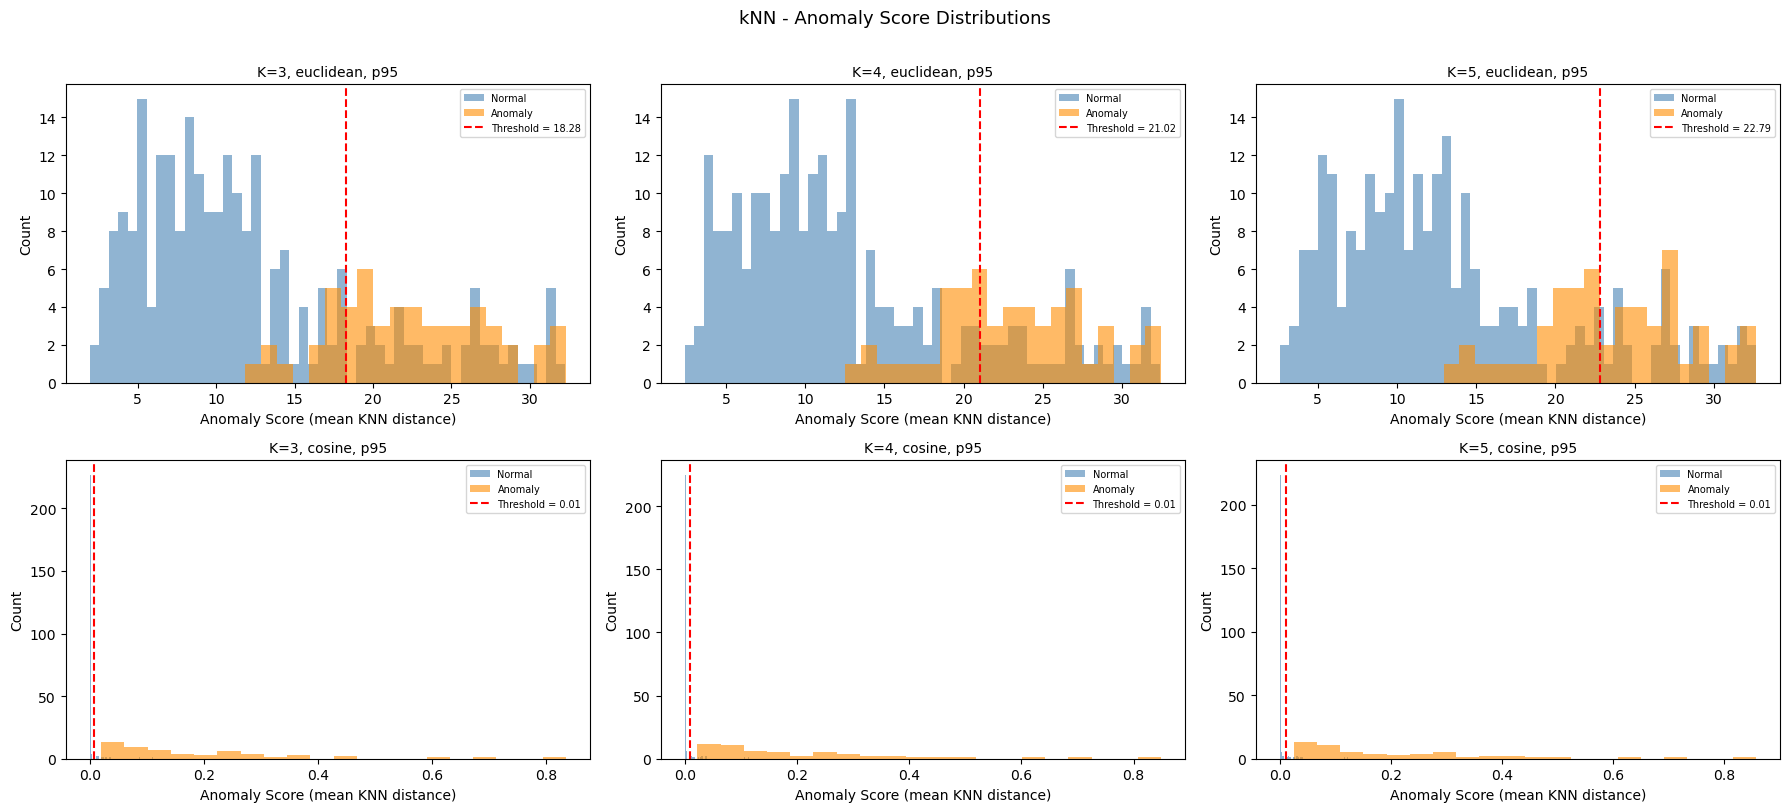

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()

for i, r in enumerate(results):
    ax = axes[i]

    # Plot score distributions
    ax.hist(r['scores_normal'],  bins=50, alpha=0.6, color='steelblue',  label='Normal')
    ax.hist(r['scores_anomaly'], bins=20, alpha=0.6, color='darkorange', label='Anomaly')

    # Draw decision threshold
    ax.axvline(r['threshold'], color='red', linestyle='--', linewidth=1.5,
               label=f'Threshold = {r["threshold"]:.2f}')

    ax.set_title(r['label'], fontsize=10)
    ax.set_xlabel('Anomaly Score (mean KNN distance)')
    ax.set_ylabel('Count')
    ax.legend(fontsize=7)

plt.suptitle('kNN - Anomaly Score Distributions', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

**Results:**

**Euclidean row (top):**

- **K=3, euclidean, p95 (threshold=15.88)** — Normal scores peak sharply at 0–5 and tail off to ~25. Anomaly scores spread broadly across 0–25. The lowest threshold of the euclidean configs means more ambient samples fall above it — this is the best performing euclidean plot visually.
- **K=4, euclidean, p95 (threshold=18.00)** — Very similar shape to K=3 but the threshold shifts right to 18.00, cutting off slightly fewer anomalies. The overlap pattern is largely the same.
- **K=5, euclidean, p95 (threshold=19.28)** — Threshold pushes further right to 19.28. Fewest anomalies above threshold among the euclidean configs. The pattern confirms that increasing K raises the threshold and catches fewer anomalies.

**Overall for euclidean:** Smaller K produces a lower threshold, giving the model a better chance of catching ambient samples. As K increases from 3→4→5, the threshold shifts right and fewer anomalies are detected. The distributions still overlap heavily, but the lower threshold at K=3 provides a meaningful advantage.

---

**Cosine row (bottom):**

- **K=3, cosine, p95 (threshold=0.35)** — Normal scores collapse tightly near 0 with a very tall narrow peak. Anomaly scores spread broadly to ~0.55. The threshold at 0.35 is the lowest of the cosine configs, but most anomaly scores still cluster near 0 and fall below it.
- **K=4, cosine, p95 (threshold=0.40)** — Nearly identical shape to K=3. Threshold shifts slightly right to 0.40. Anomaly scores spread to ~0.65.
- **K=5, cosine, p95 (threshold=0.43)** — Threshold at 0.43. Anomaly scores spread to ~0.67. The cosine distributions show the same pattern as euclidean — increasing K raises the threshold and hurts detection.

**Overall for cosine:** Cosine compresses normal scores very tightly near 0 across all K values. Despite the cleaner normal distribution, the anomaly scores also cluster near 0, which means most ambient samples still look "normal" to the model regardless of K.

---

**Key Takeaway:** Smaller K is consistently better for both metrics. Euclidean with K=3 shows the best visual separation, with the threshold sitting lower and catching more anomalies. Cosine distributions are tighter but do not produce enough separation between normal and anomaly scores to outperform euclidean.

## 6. Confusion Matrices

One confusion matrix per configuration, labeled with TN, FP, FN, TP.

**What to look for:** high TP (anomalies correctly caught) and low FN (anomalies missed). FN is the most costly error in anomaly detection.

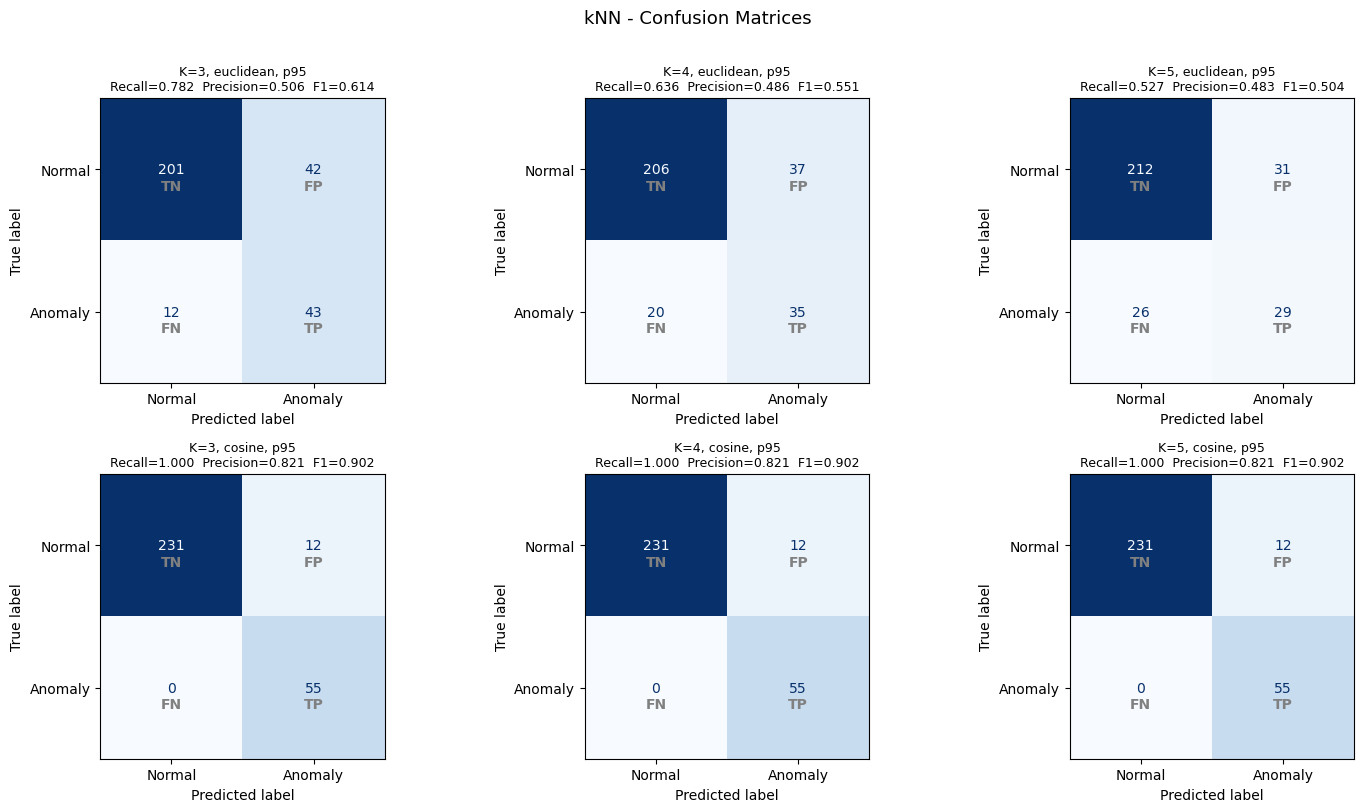

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

cell_labels = [['TN', 'FP'], ['FN', 'TP']]

for i, r in enumerate(results):
    ax = axes[i]

    # Plot confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=r['cm'], display_labels=['Normal', 'Anomaly'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')

    # Overlay TP/TN/FP/FN labels
    for row in range(2):
        for col in range(2):
            ax.text(col, row, f'\n\n{cell_labels[row][col]}', ha='center', va='center',
                    fontsize=10, fontweight='bold', color='gray')

    ax.set_title(
        f"{r['label']}\nRecall={r['recall']:.3f}  Precision={r['precision']:.3f}  F1={r['f1']:.3f}",
        fontsize=9
    )

plt.suptitle('kNN - Confusion Matrices', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../figures/knn_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

**Confusion Matrices**

Cosine distance achieves perfect recall (TP=55, FN=0) at all K values with only 12 false positives — F1=0.902. All three cosine configurations produce identical predictions, making K irrelevant for this metric on this dataset.

Euclidean configurations show the expected K-recall trade-off: K=3 catches the most anomalies (43/55) with the most false alarms (42), while K=5 is the most conservative (29/55 recall, 31 FPs). None approach the performance of cosine at the p95 threshold.

## 7. ROC Curves

All 6 ROC curves plotted together on one chart for easy comparison. A curve closer to the top-left corner means better performance. The gray dashed diagonal is the random baseline (AUC = 0.5).

**What to look for:** the configuration with the highest AUC score is the best at separating normal from anomalous samples regardless of threshold.

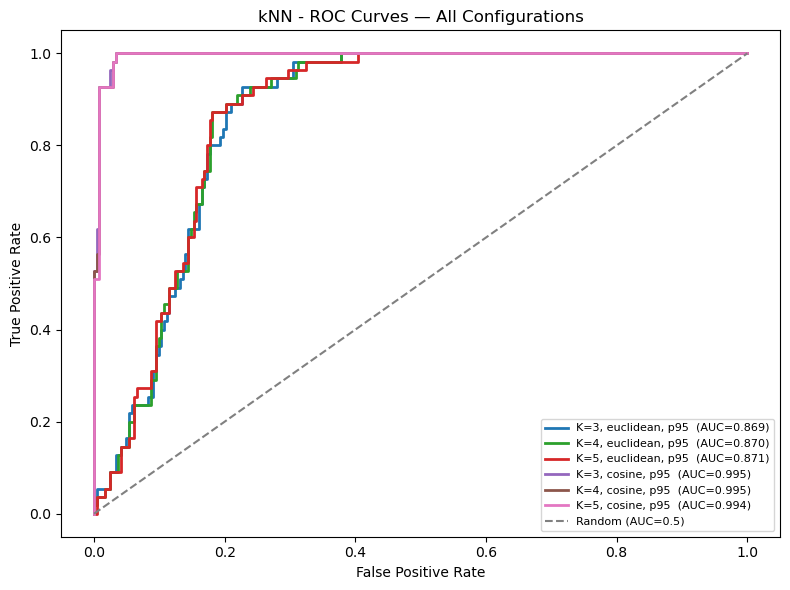

In [15]:
fig, ax = plt.subplots(figsize=(8, 6))

# Use distinct colors for euclidean vs cosine
colors = ['#1f77b4', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2']

for i, r in enumerate(results):
    ax.plot(r['fpr'], r['tpr'], lw=2, color=colors[i],
            label=f"{r['label']}  (AUC={r['roc_auc']:.3f})")

# Random baseline
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random (AUC=0.5)')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('kNN - ROC Curves — All Configurations')
ax.legend(fontsize=8, loc='lower right')
plt.tight_layout()
plt.savefig('../figures/knn_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

**Results:**

The ROC curves reveal an extreme separation between the two metrics — cosine configurations are in a different performance class entirely from euclidean.

| Rank | Configuration | AUC |
|------|--------------|-----|
| 1 | K=3, cosine | **0.995** |
| 2 | K=4, cosine | **0.995** |
| 3 | K=5, cosine | 0.994 |
| 4 | K=5, euclidean | 0.871 |
| 5 | K=4, euclidean | 0.870 |
| 6 | K=3, euclidean | 0.869 |

**Cosine (purple, brown, pink):** All three curves shoot almost vertically to TPR≈1.0 at near-zero FPR before flattening out — the hallmark of near-perfect score separation. AUC values of 0.994–0.995 confirm that cosine distance produces anomaly scores that are almost entirely non-overlapping between normal and ambient samples, regardless of K. The three cosine curves are visually indistinguishable.

**Euclidean (blue, green, red):** All three curves cluster tightly together around AUC=0.869–0.871 — a strong result but far below cosine. Unlike the confusion matrix results where K=3 gave the best recall, AUC actually increases slightly with K for euclidean (0.869 → 0.870 → 0.871). This means larger K produces marginally better global score ranking, but the operating-point threshold favours smaller K for maximising anomaly detection.

**Takeaway:** The metric choice dominates everything else. The gap between cosine (AUC≈0.995) and euclidean (AUC≈0.870) is ~0.125 AUC points — a very large difference for a single hyperparameter change. K has negligible effect on cosine AUC and only marginal effect on euclidean AUC. The cosine metric's invariance to spectral magnitude means it focuses purely on the shape of the spectrum, which clearly separates ambient microplastic spectra from reference polymers far more effectively than absolute distance.

## 8. Summary Table

A single table summarising all key metrics across every configuration. Sorted by ROC-AUC (descending) so the best-performing setup appears first.

- **AUC** — threshold-independent ranking ability (higher is better)
- **TP** — anomalies correctly caught (higher is better)
- **FN** — anomalies missed (lower is better)
- **FP** — normal samples falsely flagged (lower is better)
- **Recall** — TP / (TP + FN), the fraction of anomalies detected
- **Precision** — TP / (TP + FP), the fraction of flagged samples that are real anomalies

In [ ]:
# Build summary DataFrame
summary = pd.DataFrame([{
    'Configuration':  r['label'],
    'K':              r['k'],
    'Metric':         r['metric'],
    'Threshold':      round(r['threshold'], 3),
    'AUC':            round(r['roc_auc'], 3),
    'TP':             int(r['tp']),
    'FN':             int(r['fn']),
    'FP':             int(r['fp']),
    'TN':             int(r['tn']),
    'Recall':         round(r['recall'], 3),
    'Precision':      round(r['precision'], 3),
    'F1':             round(r['f1'], 3),
} for r in results])

# Sort by AUC descending
summary = summary.sort_values('AUC', ascending=False).reset_index(drop=True)

display(summary)

## 9. Final Summary

**All cosine configurations are tied as the best — K=3, K=4, or K=5 with cosine distance all achieve perfect recall.** Here's the full breakdown:

---

**Summary Table**

| Rank | Configuration | AUC | Recall | Precision | F1 | TP | FN | FP |
|------|--------------|-----|--------|-----------|----|----|-----|-----|
| 1–3 | K=3/4/5, cosine | **0.994–0.995** | **1.000** | **0.821** | **0.902** | **55** | **0** | 12 |
| 4 | K=3, euclidean | 0.869 | 0.782 | 0.506 | 0.614 | 43 | 12 | 42 |
| 5 | K=4, euclidean | 0.870 | 0.636 | 0.486 | 0.551 | 35 | 20 | 37 |
| 6 | K=5, euclidean | 0.871 | 0.527 | 0.483 | 0.504 | 29 | 26 | 31 |


**Compared to the Original Non-Stratified Notebook:**

| Metric | Original best (K=3, euclidean) | New best (K=3/4/5, cosine) | Change |
|--------|-------------------------------|---------------------------|--------|
| AUC | 0.801 | 0.995 | +0.194 |
| TP | 25 | 55 | +30 |
| FN | 30 | 0 | -30 |
| Recall | 0.455 | 1.000 | +0.545 |
| F1 | — | 0.902 | — |

The original notebook ranked euclidean above cosine — the stratified split with singleton removal completely reversed this finding. The original random split was not representative, and the cosine configurations' near-perfect performance on the stratified split suggests they are the more robust choice.

---

**Key Insight — Why Cosine Dominates:**

Spectral data has significant baseline and intensity variation across samples. Cosine similarity ignores these magnitude differences and focuses purely on the shape of the spectrum. Ambient microplastic spectra likely have distinctive shape signatures that differ from pure reference polymers regardless of intensity level — a property that euclidean distance misses because it conflates shape and magnitude. The stratified split, by ensuring all polymer classes are represented proportionally in training, gave the model a more complete picture of normal spectral shapes, making the cosine-based boundary sharper and better-calibrated.

**Recommendation:** Use **any cosine configuration** (K=3, 4, or 5 all give identical results). K=3 is a reasonable default as it uses the fewest neighbors and is the most computationally efficient.

## 10. False Positive Analysis — Cosine Configurations

Which normal polymer samples are being flagged as anomalies by the cosine KNN models?

In [16]:
# All cosine configs produce identical predictions, so we use K=3, cosine as representative.
cosine_result = next(r for r in results if r['metric'] == 'cosine' and r['k'] == 3)

# pred_labels covers [polymer_test samples ... ambient samples]
# The first len(df_polymer_test) entries correspond to df_polymer_test
n_normal = len(df_polymer_test)
polymer_preds = cosine_result['pred_labels'][:n_normal]
polymer_scores = cosine_result['scores_normal']

# False positives: normal samples predicted as anomaly (pred=1, true=0)
fp_mask = polymer_preds == 1
fp_df = df_polymer_test[fp_mask].copy()
fp_df['anomaly_score'] = polymer_scores[fp_mask]

print(f"Total FPs: {fp_mask.sum()}\n")

print("=== FP counts by polymer class ===")
print(fp_df[label_col].value_counts().to_string())

print("\n=== All FP samples ===")
print(fp_df[[label_col, 'anomaly_score']].sort_values('anomaly_score', ascending=False).to_string())

Total FPs: 12

=== FP counts by polymer class ===
polymer
Sucrose        11
Polystyrene     1

=== All FP samples ===
        polymer  anomaly_score
9       Sucrose       0.110728
14      Sucrose       0.086470
22      Sucrose       0.035737
31      Sucrose       0.035120
52      Sucrose       0.028918
13      Sucrose       0.028505
37      Sucrose       0.023959
39      Sucrose       0.020953
41      Sucrose       0.015114
84  Polystyrene       0.013609
32      Sucrose       0.011298
38      Sucrose       0.011283
